In [1]:
import tensorflow as tf

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [2]:
!pip install pytorch-pretrained-bert pytorch-nlp

In [3]:
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from pytorch_pretrained_bert import BertTokenizer, BertConfig
from pytorch_pretrained_bert import BertAdam, BertForSequenceClassification
from tqdm import tqdm, trange
import pandas as pd
import io
import numpy as np
import matplotlib.pyplot as plt
# % matplotlib inline

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpu = torch.cuda.device_count()
torch.cuda.get_device_name(0)

'Tesla T4'

In [5]:
from google.colab import files
uploaded = files.upload()

Saving train_10k.txt to train_10k.txt


In [6]:
with open ("train_10k.txt","r") as file:
  text=file.read()

file.close()

In [7]:
text

'__label__Hindi aisee bachat hamein una sthitiyon mein bhee sahaayata karati haye , jaba humm kamai karane mein saksham naheen hotey hain , udaaharan key liye sevaanivritti key baad .\n__label__Malayalam kramanugathamaayi eee alavu kootti 15 varsham ( praayapoortthi ) aakumbol oro maratthinum 50 kiloo pachila / compoost / jaiva valangalil eathenkilum onnum 500:250:100 gram kanakkil raasavalavum nalkanam .\n__label__Sindhi mislan : musjid nabvi jee qareeb hikk board tee likhyal dithham :\n__label__Telugu haikortu nambaru prakaram :\n__label__Konkani samajik samatayechyo baryoch ghoshana karoon legeet hyaa deshant nigro khaatir jaay tashe hakk hanga naat .\n__label__Punjabi jailh jaanh vaale jatthe noon ravana kardiaan sree panoon neey kiha kii \\ \' jailh bharo \\ \' andolan lagatar jaari rahega atey aaunde kujh dinan takk bibiaan dey jatthe vee jailh bharo andolan witch shamal qarr ditte jaange .\n__label__Maithili geet merae khaga baal !\n__label__Kashmiri R I hom \' sund hemak sund h

In [8]:
data=text.split("__label__")

In [9]:
data_for_df={"label":[],"sentence":[]}
for d in data:
  if len(d)==0 : continue
  split_data=d.split(" ")
  data_for_df["label"].append(split_data[0])
  data_for_df["sentence"].append(" ".join(split_data[1:]))

In [10]:
df=pd.DataFrame(data_for_df)

In [11]:
df.shape

(10000, 2)

In [33]:
df.sample(10)

,label,sentence
1324,Sindhi,bee shaadi karen jee karee heay maau khee pasa...
9584,Telugu,"rakaalaina hetch , hetch , bii .\n"
6516,Other,El plan hay que mirarlo a largo plazo .\n
6526,Other,"For further information , please visit www . i..."
2555,Kannada,abhimanigalu ee suddi keli khushipaduvudaralli...
3120,Maithili,"uskee khwaahish maen tumhara sara haiy , tumko..."
9918,Tamil,mariam noohani 1932 suun 19 andru paakkiththaa...
4851,Bangla,"morgan jotota ashwas dilen , totota kii toiri ..."
6704,Maithili,"kyaa dhartee , taare , chanda , ravi .\n"
3221,Telugu,suddulu ettukoni tirigetappudu konni boothu pa...


In [13]:
# Create sentence and label lists
sentences = df.sentence.values
print(sentences[:10])
print("length of sentence : ",len(sentences))
# We need to add special tokens at the beginning and end of each sentence for BERT to work properly
sentences = ["[CLS] " + sentence + " [SEP]" for sentence in sentences]
labels = df.label.values
print(labels[:10])
print("length of labels : ",len(labels))

['aisee bachat hamein una sthitiyon mein bhee sahaayata karati haye , jaba humm kamai karane mein saksham naheen hotey hain , udaaharan key liye sevaanivritti key baad .\n'
 'kramanugathamaayi eee alavu kootti 15 varsham ( praayapoortthi ) aakumbol oro maratthinum 50 kiloo pachila / compoost / jaiva valangalil eathenkilum onnum 500:250:100 gram kanakkil raasavalavum nalkanam .\n'
 'mislan : musjid nabvi jee qareeb hikk board tee likhyal dithham :\n'
 'haikortu nambaru prakaram :\n'
 'samajik samatayechyo baryoch ghoshana karoon legeet hyaa deshant nigro khaatir jaay tashe hakk hanga naat .\n'
 "jailh jaanh vaale jatthe noon ravana kardiaan sree panoon neey kiha kii \\ ' jailh bharo \\ ' andolan lagatar jaari rahega atey aaunde kujh dinan takk bibiaan dey jatthe vee jailh bharo andolan witch shamal qarr ditte jaange .\n"
 'geet merae khaga baal !\n'
 "R I hom ' sund hemak sund hom ' sɨnd ' hemak sende hum ' sɨnz huim senz\n"
 'yathaa sankhyabhyupagatani panchavimshatitattvaani , eteshaa

In [14]:
sentences[:10]

['[CLS] aisee bachat hamein una sthitiyon mein bhee sahaayata karati haye , jaba humm kamai karane mein saksham naheen hotey hain , udaaharan key liye sevaanivritti key baad .\n [SEP]',
 '[CLS] kramanugathamaayi eee alavu kootti 15 varsham ( praayapoortthi ) aakumbol oro maratthinum 50 kiloo pachila / compoost / jaiva valangalil eathenkilum onnum 500:250:100 gram kanakkil raasavalavum nalkanam .\n [SEP]',
 '[CLS] mislan : musjid nabvi jee qareeb hikk board tee likhyal dithham :\n [SEP]',
 '[CLS] haikortu nambaru prakaram :\n [SEP]',
 '[CLS] samajik samatayechyo baryoch ghoshana karoon legeet hyaa deshant nigro khaatir jaay tashe hakk hanga naat .\n [SEP]',
 "[CLS] jailh jaanh vaale jatthe noon ravana kardiaan sree panoon neey kiha kii \\ ' jailh bharo \\ ' andolan lagatar jaari rahega atey aaunde kujh dinan takk bibiaan dey jatthe vee jailh bharo andolan witch shamal qarr ditte jaange .\n [SEP]",
 '[CLS] geet merae khaga baal !\n [SEP]',
 "[CLS] R I hom ' sund hemak sund hom ' sɨnd ' h

In [15]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)
tokenized_texts = [tokenizer.tokenize(sent) for sent in sentences]
print ("Tokenize the first sentence:")
print (tokenized_texts[1])

100%|██████████| 231508/231508 [00:00<00:00, 1264110.27B/s]


Tokenize the first sentence:
['[CLS]', 'k', '##rama', '##nu', '##gat', '##ham', '##aa', '##yi', 'ee', '##e', 'ala', '##vu', 'ko', '##otti', '15', 'var', '##sham', '(', 'pr', '##aa', '##ya', '##poo', '##rt', '##thi', ')', 'aa', '##ku', '##mbo', '##l', 'oro', 'mara', '##tt', '##hin', '##um', '50', 'ki', '##lo', '##o', 'pac', '##hila', '/', 'com', '##poo', '##st', '/', 'jai', '##va', 'val', '##anga', '##li', '##l', 'eat', '##hen', '##ki', '##lum', 'on', '##num', '500', ':', '250', ':', '100', 'gram', 'kan', '##ak', '##ki', '##l', 'ra', '##asa', '##val', '##av', '##um', 'na', '##lka', '##nam', '.', '[SEP]']


In [16]:
MAX_LEN = 128

In [17]:
# Pad our input tokens
input_ids = pad_sequences([tokenizer.convert_tokens_to_ids(txt) for txt in tokenized_texts],
                          maxlen=MAX_LEN, dtype="long", truncating="post", padding="post")

In [18]:
input_ids[1]

array([  101,  1047, 14672, 11231, 20697,  3511, 11057, 10139, 25212,
        2063, 21862, 19722, 12849, 21325,  2321, 13075, 21010,  1006,
       10975, 11057,  3148, 24667,  5339, 15222,  1007,  9779,  5283,
       13344,  2140, 20298, 13955,  4779, 10606,  2819,  2753, 11382,
        4135,  2080, 14397, 26415,  1013,  4012, 24667,  3367,  1013,
       17410,  3567, 11748, 18222,  3669,  2140,  4521, 10222,  3211,
       12942,  2006, 19172,  3156,  1024,  5539,  1024,  2531, 13250,
       22827,  4817,  3211,  2140, 10958, 16782, 10175, 11431,  2819,
        6583, 26518, 13129,  1012,   102,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0]

In [19]:
# Create attention masks
attention_masks = []

# Create a mask of 1s for each token followed by 0s for padding
for seq in input_ids:
  seq_mask = [float(i>0) for i in seq]
  attention_masks.append(seq_mask)

In [20]:
print(attention_masks[1])

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [21]:
train_inputs, validation_inputs = train_test_split(input_ids,random_state=2018, test_size=0.1)
train_masks, validation_masks, _, _ = train_test_split(attention_masks, input_ids,
                                             random_state=2018, test_size=0.1)

In [22]:
unique_labels = np.unique(labels)
unique_labels

array(['Assamese', 'Bangla', 'Bodo', 'English', 'Gujarati', 'Hindi',
       'Kannada', 'Kashmiri', 'Konkani', 'Maithili', 'Malayalam',
       'Manipuri_Mei', 'Marathi', 'Nepali', 'Oriya', 'Other', 'Punjabi',
       'Sanskrit', 'Sindhi', 'Tamil', 'Telugu', 'Urdu'], dtype=object)

In [23]:
number_of_labels = len(unique_labels)
number_of_labels

22

In [24]:
label_map = {label: i for i, label in enumerate(unique_labels)}

# Convert labels to numerical IDs
numerical_labels = np.array([label_map[label] for label in labels])

# Split the numerical labels into training and validation sets
train_labels, validation_labels = train_test_split(numerical_labels,
                                                            random_state=2018, test_size=0.1)

In [25]:
# Convert all of our data into torch tensors, the required datatype
train_inputs = torch.tensor(train_inputs)
validation_inputs = torch.tensor(validation_inputs)
train_labels = torch.tensor(train_labels)
validation_labels = torch.tensor(validation_labels)
train_masks = torch.tensor(train_masks)
validation_masks = torch.tensor(validation_masks)

In [26]:
batch_size = 32

train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

validation_data = TensorDataset(validation_inputs, validation_masks, validation_labels)
validation_sampler = SequentialSampler(validation_data)
validation_dataloader = DataLoader(validation_data, sampler=validation_sampler, batch_size=batch_size)


In [27]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=number_of_labels)
model.cuda()

100%|██████████| 407873900/407873900 [00:07<00:00, 52148008.67B/s]


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): BertLayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): BertLayerNorm()
              (dropout): Dropout(p=0.1, inplace=Fa

In [34]:

param_optimizer = list(model.named_parameters())
no_decay = ['bias', 'gamma', 'beta']
optimizer_grouped_parameters = [
    {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)],
     'weight_decay_rate': 0.01},
    {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
     'weight_decay_rate': 0.0}
]



In [35]:
optimizer = BertAdam(optimizer_grouped_parameters,
                     lr=2e-5,
                     warmup=.1)

In [30]:
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

In [36]:
# Store our loss and accuracy for plotting
train_loss_set = []

# Number of training epochs (authors recommend between 2 and 4)
epochs = 4

# trange is a tqdm wrapper around the normal python range
for _ in trange(epochs, desc="Epoch"):


  # Training

  # Set our model to training mode (as opposed to evaluation mode)
  model.train()

  # Tracking variables
  tr_loss = 0
  nb_tr_examples, nb_tr_steps = 0, 0

  # Train the data for one epoch
  for step, batch in enumerate(train_dataloader):
    # Add batch to GPU
    batch = tuple(t.to(device) for t in batch)
    # Unpack the inputs from our dataloader
    b_input_ids, b_input_mask, b_labels = batch
    # Clear out the gradients (by default they accumulate)
    optimizer.zero_grad()
    # Forward pass
    loss = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
    train_loss_set.append(loss.item())
    # Backward pass
    loss.backward()
    # Update parameters and take a step using the computed gradient
    optimizer.step()


    # Update tracking variables
    tr_loss += loss.item()
    nb_tr_examples += b_input_ids.size(0)
    nb_tr_steps += 1

  print("Train loss: {}".format(tr_loss/nb_tr_steps))


  # Validation

  # Put model in evaluation mode to evaluate loss on the validation set
  model.eval()

  # Tracking variables
  eval_loss, eval_accuracy = 0, 0
  nb_eval_steps, nb_eval_examples = 0, 0

  # Evaluate data for one epoch
  for batch in validation_dataloader:
    # Add batch to GPU
    batch = tuple(t.to(device) for t in batch)
    # Unpack the inputs from our dataloader
    b_input_ids, b_input_mask, b_labels = batch
    # Telling the model not to compute or store gradients, saving memory and speeding up validation
    with torch.no_grad():
      # Forward pass, calculate logit predictions
      logits = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

    # Move logits and labels to CPU
    logits = logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()

    tmp_eval_accuracy = flat_accuracy(logits, label_ids)

    eval_accuracy += tmp_eval_accuracy
    nb_eval_steps += 1

  print("Validation Accuracy: {}".format(eval_accuracy/nb_eval_steps))

Epoch:   0%|          | 0/4 [00:00<?, ?it/s]

Train loss: 1.1894828946666514


Epoch:  25%|██▌       | 1/4 [03:41<11:03, 221.24s/it]

Validation Accuracy: 0.7724609375
Train loss: 0.42055615426061


Epoch:  50%|█████     | 2/4 [07:23<07:23, 221.58s/it]

Validation Accuracy: 0.8623046875
Train loss: 0.17684638255824012


Epoch:  75%|███████▌  | 3/4 [11:04<03:41, 221.61s/it]

Validation Accuracy: 0.8828125
Train loss: 0.08568772677900204


Epoch: 100%|██████████| 4/4 [14:46<00:00, 221.64s/it]

Validation Accuracy: 0.8955078125


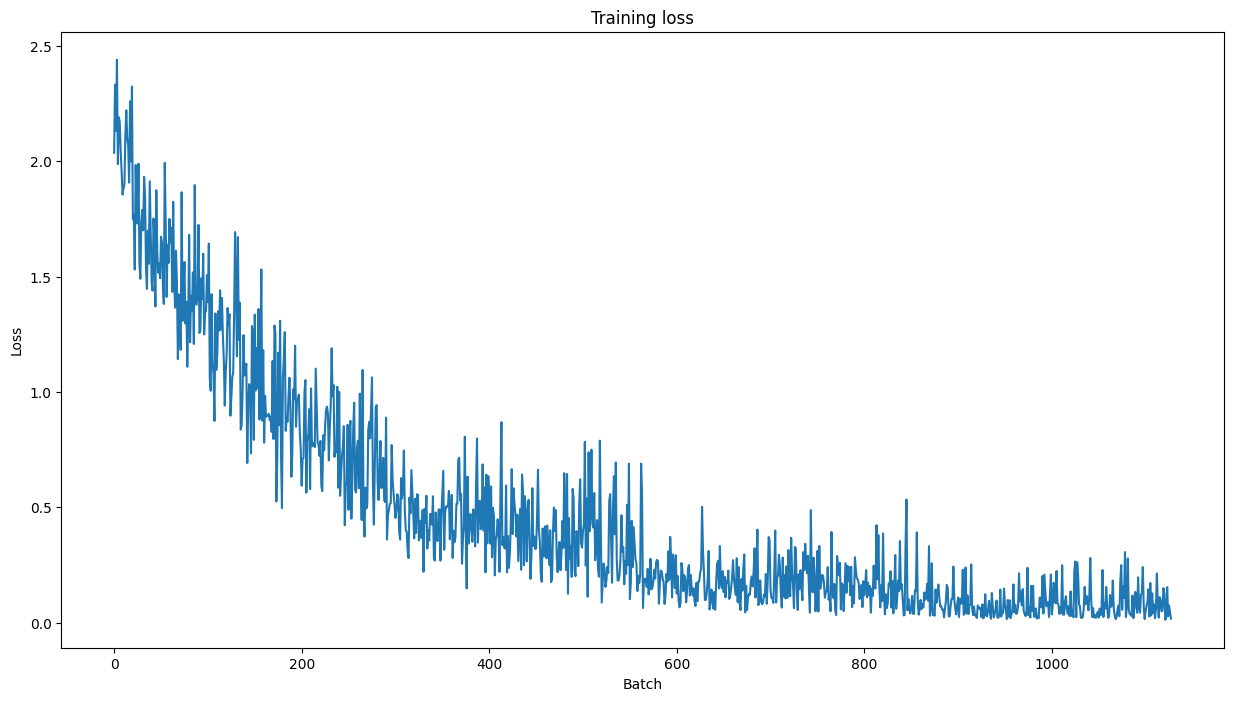

In [37]:
plt.figure(figsize=(15,8))
plt.title("Training loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.plot(train_loss_set)
plt.show()

##Predict and Evaluate

In [38]:
# Upload the test file from your local drive
from google.colab import files
uploaded = files.upload()


Saving val_1k.txt to val_1k.txt


In [39]:
with open ("val_1k.txt","r") as file:
  text=file.read()

file.close()

text

'__label__Kashmiri kaafi , das eshariya chhe faisad\n__label__Assamese uttor guwahatih mohanogorit sakorir prolubhonere nibonuwar poraa dhon xongroho koraa hyprophile probonchok ojit daxok uttor guwahati arokhyiye obhijan solai aatok koriboloi xokhyom hoy .\n__label__Oriya ehaa anaswikarjya je , kaunasi eka anshare jadi balaprayoga karajae tebe tahar pratiphalana kendrare nischaya prakash paiba .\n__label__Sanskrit asya nagarasya samskrutihi samruddhaa asti .\n__label__Punjabi Punjab di lok naat paramparaa te panjaabi naatak – Dr. Rawel Singh\n__label__Kannada Pramukha gruhabalakeya vastugala vibhaagavannu whirlpool kaarporeshanhge maaraata maadida balika idu \'Philips whirlpool\' mattu \' whirlpool Philips\' moolaka \'whirlpool\' ge badalaayitu.\n__label__Bangla nadiyar maharaja srishchondro roy ebong murshidabad jelar kasimbazarer maharani swarnomoyi colleger jonne shotadhik bigha jomi daan korle sthaniyo shikhahitoishi baktiborger arthik sohojogitay 1856 chrishtabde ekti prasadogomo

In [40]:
data=text.split("__label__")
data_for_df={"label":[],"sentence":[]}
for d in data:
  if len(d)==0 : continue
  split_data=d.split(" ")
  data_for_df["label"].append(split_data[0])
  data_for_df["sentence"].append(" ".join(split_data[1:]))

In [41]:
df=pd.DataFrame(data_for_df)

In [42]:
df.sample(10)

,label,sentence
123,Maithili,floraak janm chandigadhme aeka sainik parivaar...
317,Manipuri_Mei,eromba ( roman mayek : Eromba) manipurgi meete...
965,English,"Liverpool , who had dominated possession in th..."
930,Bodo,gaswi saa 119 subungpwrnw hwyw banta kwo .\n
847,Kannada,Aadare ondu dina akasmaattaagi Oraiyanannu (Ma...
721,Malayalam,maleshyayile tin vyavasaayathinu kaalakramena ...
836,Bangla,eyi lokogulor sankhya - sirij / shreni hachche...
813,Bodo,boad ' land territoryel council sungdoywi bi ....
727,Kannada,"""Vivaravannu padeyalu mundina warada avadhiyal..."
652,Nepali,chautariaka chhoraharu balbhadra shah rar kris...


In [45]:
# Create sentence and label lists
sentences = df.sentence.values

# We need to add special tokens at the beginning and end of each sentence for BERT to work properly
sentences = ["[CLS] " + sentence + " [SEP]" for sentence in sentences]
labels = df.label.values

tokenized_texts = [tokenizer.tokenize(sent) for sent in sentences]


MAX_LEN = 128
# Pad our input tokens
input_ids = pad_sequences([tokenizer.convert_tokens_to_ids(txt) for txt in tokenized_texts],
                          maxlen=MAX_LEN, dtype="long", truncating="post", padding="post")
# Use the BERT tokenizer to convert the tokens to their index numbers in the BERT vocabulary
input_ids = [tokenizer.convert_tokens_to_ids(x) for x in tokenized_texts]
input_ids = pad_sequences(input_ids, maxlen=MAX_LEN, dtype="long", truncating="post", padding="post")
# Create attention masks
attention_masks = []

# Create a mask of 1s for each token followed by 0s for padding
for seq in input_ids:
  seq_mask = [float(i>0) for i in seq]
  attention_masks.append(seq_mask)

prediction_inputs = torch.tensor(input_ids)
prediction_masks = torch.tensor(attention_masks)
prediction_labels = torch.tensor(np.array([label_map[label] for label in labels])) # Convert labels to numerical IDs

batch_size = 32


prediction_data = TensorDataset(prediction_inputs, prediction_masks, prediction_labels)
prediction_sampler = SequentialSampler(prediction_data)
prediction_dataloader = DataLoader(prediction_data, sampler=prediction_sampler, batch_size=batch_size)

In [46]:
# Prediction on test set

# Put model in evaluation mode
model.eval()

# Tracking variables
predictions , true_labels = [], []

# Predict
for batch in prediction_dataloader:
  # Add batch to GPU
  batch = tuple(t.to(device) for t in batch)
  # Unpack the inputs from our dataloader
  b_input_ids, b_input_mask, b_labels = batch
  # Telling the model not to compute or store gradients, saving memory and speeding up prediction
  with torch.no_grad():
    # Forward pass, calculate logit predictions
    logits = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

  # Move logits and labels to CPU
  logits = logits.detach().cpu().numpy()
  label_ids = b_labels.to('cpu').numpy()

  # Store predictions and true labels
  predictions.append(logits)
  true_labels.append(label_ids)

In [47]:
# Import and evaluate each test batch using Matthew's correlation coefficient
from sklearn.metrics import matthews_corrcoef
matthews_set = []

for i in range(len(true_labels)):
  matthews = matthews_corrcoef(true_labels[i],
                 np.argmax(predictions[i], axis=1).flatten())
  matthews_set.append(matthews)

In [48]:
matthews_set

[np.float64(0.8722746135976341),
 np.float64(0.8707646661466786),
 np.float64(0.7991502918473222),
 np.float64(0.7452895841435125),
 np.float64(0.7421728073308955),
 np.float64(0.6722703911074714),
 np.float64(0.8054719362680168),
 np.float64(0.8408968136645613),
 np.float64(0.8056430730629683),
 np.float64(0.777542372881356),
 np.float64(0.7652772680144234),
 np.float64(0.772153617107471),
 np.float64(0.9016756133396647),
 np.float64(0.8372261421430821),
 np.float64(0.7725434783862609),
 np.float64(0.9339728405998641),
 np.float64(0.8698850539277266),
 np.float64(0.6074523083300883),
 np.float64(0.7439864920023002),
 np.float64(0.8373816706689519),
 np.float64(0.8392502631421097),
 np.float64(0.7008472322497652),
 np.float64(0.7463328769820485),
 np.float64(0.8025495795422938),
 np.float64(1.0),
 np.float64(0.9024139280794269),
 np.float64(0.7443888584271603),
 np.float64(0.6761337532902544),
 np.float64(0.8063175763290189),
 np.float64(0.7381207916741455),
 np.float64(0.9027196652719

In [49]:
# Flatten the predictions and true values for aggregate Matthew's evaluation on the whole dataset
flat_predictions = [item for sublist in predictions for item in sublist]
flat_predictions = np.argmax(flat_predictions, axis=1).flatten()
flat_true_labels = [item for sublist in true_labels for item in sublist]


In [51]:
print(matthews_corrcoef(flat_true_labels, flat_predictions))

0.7998743254426223
